In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Load the data
data = np.load('../data/mnist_test_seq.npy')

# Check the shape
print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Min value: {data.min()}, Max value: {data.max()}")

Data shape: (20, 10000, 64, 64)
Data type: uint8
Min value: 0, Max value: 255


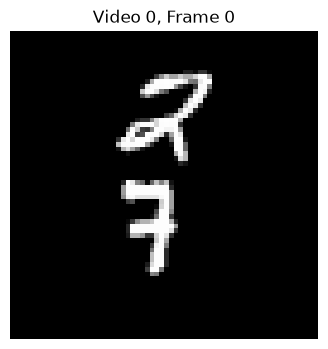

In [3]:
# Pick the first video
video_idx = 0
frame_idx = 0

frame = data[video_idx, frame_idx]

plt.figure(figsize=(4, 4))
plt.imshow(frame, cmap='gray')
plt.title(f"Video {video_idx}, Frame {frame_idx}")
plt.axis('off')
plt.show()

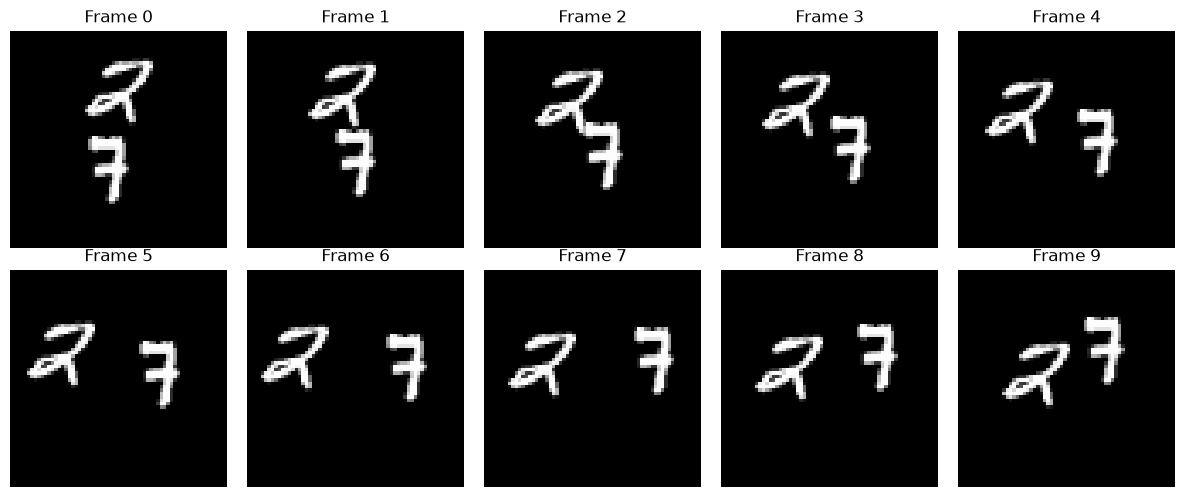

In [4]:
# Show first 10 frames of video 0
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(data[i, 0], cmap='gray')
    axes[i].set_title(f"Frame {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Pick the first video
video = data[:, 0, :, :]  # Shape: (20, 64, 64)

# Animate
fig, ax = plt.subplots(figsize=(5, 5))

def update(frame_idx):
    ax.clear()
    ax.imshow(video[frame_idx], cmap='gray')
    ax.set_title(f"Frame {frame_idx}/20")
    ax.axis('off')

anim = FuncAnimation(fig, update, frames=20, interval=100)
plt.close()

HTML(anim.to_jshtml())

Number of videos: 10000
Frames per video: 20
Image resolution: 64×64

Pixel intensity stats:
  Mean: 12.6
  Std: 51.1
  Sparsity (black pixels): 92.9%


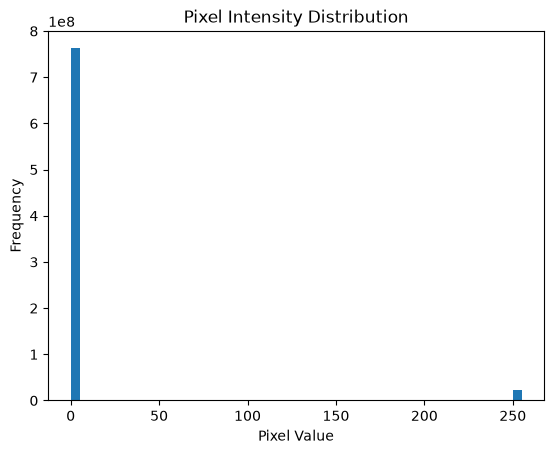

In [6]:
# How many unique videos and frames?
print(f"Number of videos: {data.shape[1]}")
print(f"Frames per video: {data.shape[0]}")
print(f"Image resolution: {data.shape[2]}×{data.shape[3]}")

# Check pixel intensity distribution
print(f"\nPixel intensity stats:")
print(f"  Mean: {data.mean():.1f}")
print(f"  Std: {data.std():.1f}")

# How sparse is it? (percentage of non-zero pixels)
sparsity = (data == 0).mean() * 100
print(f"  Sparsity (black pixels): {sparsity:.1f}%")

# Visualize intensity distribution
plt.hist(data.flatten(), bins=50)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution')
plt.show()